<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
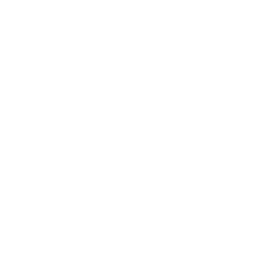
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Power Transformer Accelerated Life Testing</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Energy / Asset Reliability &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

This study fits an **Arrhenius-Weibull accelerated life model** to
high-voltage power-transformer insulation, using temperature as the
accelerating stress. Specimens are aged at three elevated
temperatures — 130°C, 150°C and 170°C — and the resulting failure
times feed a `PROC RELIABILITY` regression of log-life on inverse
absolute temperature. The fitted relationship is then extrapolated to
the normal operating temperature of 85°C to support fleet
replacement scheduling.

The accelerating effect is strong and highly significant: the slope on
inverse absolute temperature is **10.50** (Z = 25.4, p < 0.0001),
which corresponds to a recovered activation energy of **0.90 eV** —
at the lower edge of the 0.9–1.1 eV range reported for thermal aging
of cellulose insulation. Extrapolated to 85°C, the model predicts a
characteristic life (Weibull η) of about **304,000 hours** and a
**mean time to failure of 30.9 years**, with a Weibull shape of
**2.70** confirming a pronounced wear-out mechanism. At the 30-year
design-life target the predicted reliability is **51%**, so roughly
**49% of units operated continuously at 85°C** would be expected to
require refurbishment or replacement before 30 years.

Scoring a 60-unit fleet against its individual operating temperatures,
the model flags **20 transformers** with less than ten years of
remaining life — the units that should be prioritized in the next
capital-improvement cycle.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.ALT_TRANSFORMER | Accelerated test results at 3 stress levels (33 specimens each) | 99 |
| WORK.FLEET_OPERATING | In-service fleet operating-temperature profiles | 60 |

The accelerated-test data are synthetic, generated from a Weibull life
model whose scale parameter follows an Arrhenius temperature
relationship (generating shape ≈ 2.5, target activation energy ≈ 1 eV).
A small fraction of specimens are right-censored at the test cut-off,
mirroring units that survive the test window. The fitted model recovers
a Weibull shape of 2.70 and an activation energy of 0.90 eV, close to
the generating values.

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic accelerated life test data.
   Three temperature stress levels in a SINGLE data step
   so all levels survive the 100-observation preview cap
   (33 specimens each = 99 rows). Weibull failure times
   (shape ~2.5) with an Arrhenius scale-temperature law;
   activation energy ~1 eV, typical for insulation aging.
   -------------------------------------------------------- */
data work.alt_transformer;
    call streaminit(42);
    array stress_temps[3]  _temporary_ (130 150 170);
    /* Weibull scale (hours) at each test temperature,
       chosen so the Arrhenius fit extrapolates to a
       realistic multi-decade life at 85C use. */
    array scale_at_temp[3] _temporary_ (11573 3401 1117);
    n_per_temp = 33;
    do temp_idx = 1 to 3;
        test_temp_c = stress_temps[temp_idx];
        test_temp_k = test_temp_c + 273.15;
        /* Arrhenius covariate: 1000 / absolute temperature */
        inv_temp_k = 1000 / test_temp_k;
        do unit = 1 to n_per_temp;
            specimen_id = cat('TX-', put(test_temp_c, z3.),
                              '-', put(unit, z2.));
            /* Weibull failure time: shape = 2.5 */
            weibull_life = scale_at_temp[temp_idx]
                           * ((-log(rand('uniform'))) ** (1 / 2.5));
            /* Right-censor specimens still running at test cut-off */
            test_cutoff = scale_at_temp[temp_idx] * 1.6;
            if weibull_life <= test_cutoff then do;
                hours_to_event = round(weibull_life, 1);
                censored = 0;
            end;
            else do;
                hours_to_event = round(test_cutoff, 1);
                censored = 1;
            end;
            rated_voltage_kv = 138;
            output;
        end;
    end;
    keep specimen_id test_temp_c test_temp_k inv_temp_k
         hours_to_event censored rated_voltage_kv;
run;

NOTE: DATA work.alt_transformer


NOTE: Wrote work.alt_transformer (99 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   In-service fleet: average operating temperature and
   accumulated service age for 60 transformers. These feed
   the unit-specific life predictions later in the notebook.
   -------------------------------------------------------- */
data work.fleet_operating;
    call streaminit(43);
    do transformer_id = 1 to 60;
        asset_tag = cat('FLEET-', put(transformer_id, z4.));
        substation = cat('SUB-',
                         put(int(rand('uniform') * 12) + 1, z3.));
        avg_operating_temp_c = round(rand('normal', 85, 9), 0.1);
        if avg_operating_temp_c < 62  then avg_operating_temp_c = 62;
        if avg_operating_temp_c > 108 then avg_operating_temp_c = 108;
        peak_loading_pct = round(rand('normal', 72, 15), 1);
        install_year = 2000 + int(rand('uniform') * 22);
        service_years = 2026 - install_year;
        output;
    end;
    keep asset_tag substation avg_operating_temp_c
         peak_loading_pct install_year service_years;
run;

NOTE: DATA work.fleet_operating


NOTE: Wrote work.fleet_operating (60 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Baseline: specimen counts, censoring, and mean test life
   at each accelerating temperature.
   -------------------------------------------------------- */
proc sql;
    select test_temp_c,
           count(*)                                  as n_specimens,
           sum(censored)                             as n_censored,
           sum(case when censored = 0 then 1 else 0 end) as n_failed,
           round(mean(hours_to_event), 0)            as avg_hours
    from work.alt_transformer
    group by test_temp_c
    order by test_temp_c;
quit;

test_temp_c  n_specimens  n_censored  n_failed  avg_hours
-----------  -----------  ----------  --------  ---------
      130.0           33         0.0        33    10737.0
      150.0           33         2.0        31     2955.0
      170.0           33         1.0        32      943.0


NOTE: PROC SQL 

NOTE: PROC SQL statement used.


---

NOTE: PROC SGPLOT data=work.alt_transformer

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


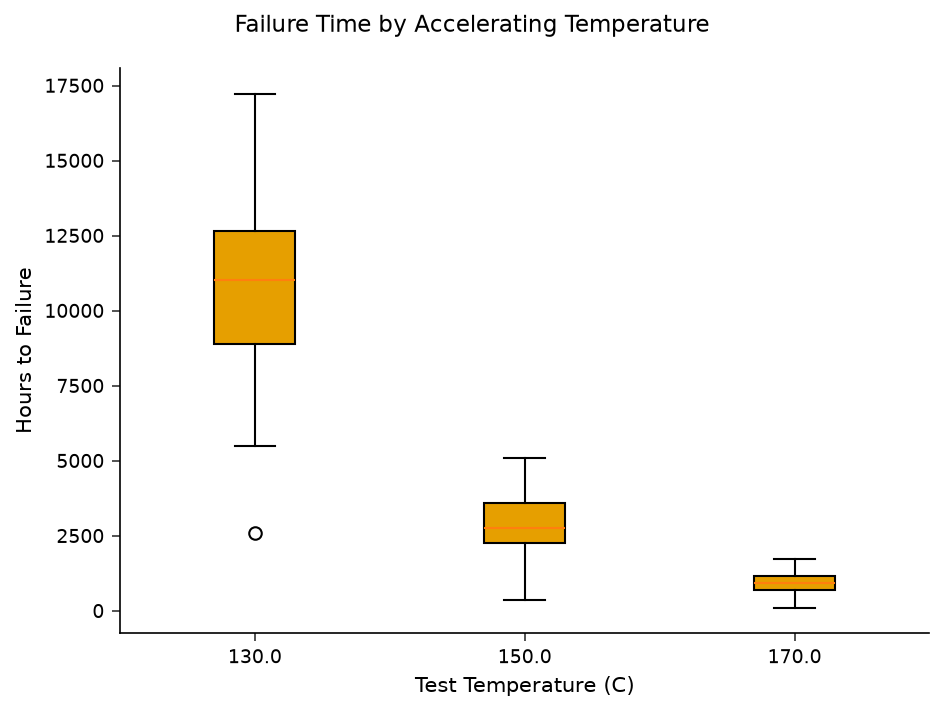

In [4]:
/* --------------------------------------------------------
   Failure-time distribution at each accelerating temperature
   (observed failures only). Higher temperature -> shorter life.
   -------------------------------------------------------- */
proc sgplot data=work.alt_transformer;
    where censored = 0;
    vbox hours_to_event / category=test_temp_c;
    xaxis label='Test Temperature (C)' type=discrete;
    yaxis label='Hours to Failure';
    title 'Failure Time by Accelerating Temperature';
run;

---


                    The RELIABILITY Procedure

  Distribution:     Weibull
  Observations:     99
  Events:           96
  Censored:         3
  Min time:         109.000000
  Max time:         17233.000000
  Mean time:        4878.424242

  Parameter Estimates (95% CI):
  Beta(shape)       0.998960   (0.853401, 1.169348)
  Eta(scale)        5028.776231   (4076.417834, 6203.630593)

  B-Life Estimates (95% CI):
  Percentile     Estimate        Lower        Upper
  B1            50.299514    38.064165    66.467796
  B5           257.146423   194.595592   339.803600
  B10          528.595080   400.014402   698.506747




NOTE: PROC RELIABILITY
NOTE: ODS plot written: reliability_hours_to_event.spec.json
NOTE: PROC RELIABILITY statement used.


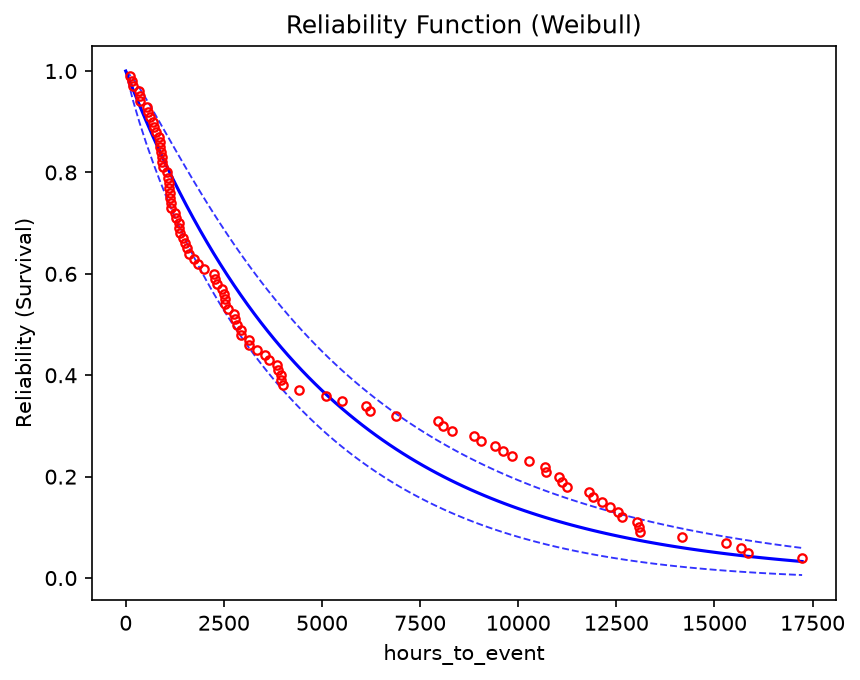

In [5]:
/* --------------------------------------------------------
   Weibull probability plot of the pooled accelerated-test
   data. The fitted reliability curve and its confidence
   band give an overall view of how well a Weibull
   distribution describes the observed failure times before
   the temperature effect is modeled explicitly.
   -------------------------------------------------------- */
proc reliability data=work.alt_transformer;
    distribution weibull;
    probplot hours_to_event*censored(1) / cframe=ligr;
    title 'Weibull Probability Plot of Accelerated Test Data';
run;


                    The RELIABILITY Procedure

  Distribution:     Weibull
  Observations:     99
  Events:           96
  Censored:         3
  Min time:         109.000000
  Max time:         17233.000000
  Mean time:        4878.424242

  Parameter Estimates (95% CI):
  Beta(shape)       2.695776   (2.291140, 3.171874)
  Eta(scale)        3494.544536   (3236.095211, 3773.634801)

  B-Life Estimates (95% CI):
  Percentile     Estimate        Lower        Upper
  B1           634.304895   514.106122   782.606318
  B5          1161.145523   941.112117  1432.623065
  B10         1516.534367  1229.155899  1871.102347

  Regression Coefficients (Accelerated Life Test Model)

  Parameter           Estimate    Std Error    Z Value   Pr > |Z|
  Intercept         -16.696965     0.981982   -17.0033     0.0000
  INV_TEMP_K         10.502108     0.414138    25.3590     0.0000
  Scale (sigma)       0.370951


                                    Fitted Arrhenius-Weibull Regression Coefficients   

NOTE: ODS OUTPUT: PARAMETERESTIMATES -> alt_params
NOTE: PROC RELIABILITY
NOTE: ODS plot written: reliability_hours_to_event.spec.json
NOTE: PROC RELIABILITY statement used.
NOTE: ODS OUTPUT: All output destinations closed.
NOTE: PROC PRINT data=work.alt_params

NOTE: PROC PRINT completed: 3 observations printed, 5 variables


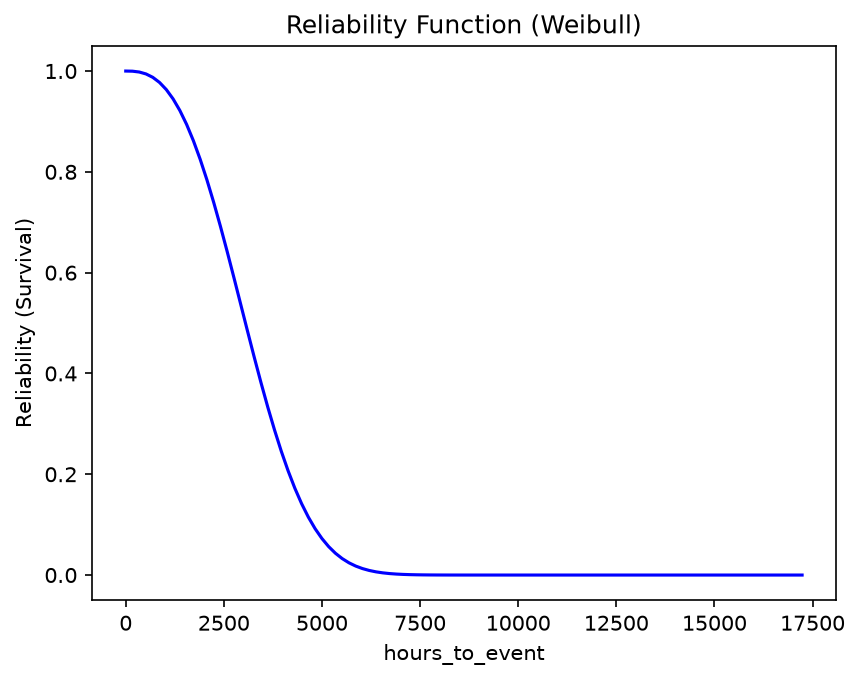

In [6]:
/* --------------------------------------------------------
   Arrhenius-Weibull accelerated life regression.
   The MODEL statement regresses log(life) on inverse
   absolute temperature (1000/K) with a Weibull
   distribution and an Arrhenius life-stress relation:
       log(eta) = b0 + b1 * (1000 / T_kelvin)
   A positive slope on 1000/K means life lengthens as
   temperature falls -- the expected Arrhenius behavior.
   The coefficient table is captured for extrapolation.
   -------------------------------------------------------- */
ods output parameterestimates=work.alt_params;

proc reliability data=work.alt_transformer;
    distribution weibull;
    model hours_to_event*censored(1) = inv_temp_k
          / distribution=weibull relation=arrhenius;
    title 'Arrhenius-Weibull ALT Regression';
run;

ods output close;

proc print data=work.alt_params noobs;
    title 'Fitted Arrhenius-Weibull Regression Coefficients';
run;

In [7]:
/* --------------------------------------------------------
   Extrapolate predicted life to the 85C operating
   temperature. The AFT regression gives, for a Weibull
   distribution: log(eta) = Intercept + slope*(1000/T_K),
   with Weibull shape = 1 / Scale(sigma).
   MTTF = eta * gamma(1 + sigma).
   -------------------------------------------------------- */
data work.use_condition_prediction;
    set work.alt_params end=last;
    retain intercept_a slope_b sigma_est;
    if upcase(parameter) = 'INTERCEPT'  then intercept_a = estimate;
    if upcase(parameter) = 'INV_TEMP_K' then slope_b     = estimate;
    if upcase(parameter) = 'SCALE'      then sigma_est   = estimate;
    if last then do;
        normal_temp_c   = 85;
        normal_inv_temp = 1000 / (normal_temp_c + 273.15);
        log_eta_at_use  = intercept_a + slope_b * normal_inv_temp;
        eta_at_use      = exp(log_eta_at_use);
        weibull_shape   = 1 / sigma_est;
        /* MTTF = eta * gamma(1 + 1/shape) = eta * gamma(1 + sigma) */
        mttf_at_use_hours = eta_at_use * gamma(1 + sigma_est);
        mttf_at_use_years = round(mttf_at_use_hours / 8760, 0.1);
        /* Activation energy (eV): Ea = k * 1000 * slope */
        activation_energy_ev = round(8.617e-5 * 1000 * slope_b, 0.01);
        /* Reliability at the 30-year design-life target */
        design_life_hours   = 30 * 8760;
        reliability_at_30yr = round(
            exp(-((design_life_hours / eta_at_use) ** weibull_shape)), 0.001);
        output;
    end;
    keep normal_temp_c eta_at_use weibull_shape activation_energy_ev
         mttf_at_use_hours mttf_at_use_years
         design_life_hours reliability_at_30yr;
run;

proc print data=work.use_condition_prediction noobs;
    title 'Predicted Transformer Life at 85C Operating Temperature';
run;

                                Predicted Transformer Life at 85C Operating Temperature                                 

NORMAL_TEMP_C         ETA_AT_USE  WEIBULL_SHAPE  ACTIVATION_ENERGY_EV  MTTF_AT_USE_HOURS  MTTF_AT_USE_YEARS  DESIGN_LIFE_HOURS  RELIABILITY_AT_30YR
           85  304445.2349995006   2.6957760057                   0.9  270723.5550585605               30.9             262800                 0.51



NOTE: DATA work.use_condition_prediction


NOTE: Read 3 rows from work.alt_params.
NOTE: Wrote work.use_condition_prediction (1 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.use_condition_prediction

NOTE: PROC PRINT completed: 1 observations printed, 8 variables


In [8]:
/* --------------------------------------------------------
   Score the in-service fleet: apply the fitted Arrhenius
   model to each transformer's average operating temperature
   to predict unit-specific MTTF and flag units with less
   than 10 years of remaining life.
   -------------------------------------------------------- */
data work.model_coef;
    set work.alt_params end=last;
    retain b0 b1 sigma;
    if upcase(parameter) = 'INTERCEPT'  then b0    = estimate;
    if upcase(parameter) = 'INV_TEMP_K' then b1    = estimate;
    if upcase(parameter) = 'SCALE'      then sigma = estimate;
    if last then output;
    keep b0 b1 sigma;
run;

data work.fleet_life;
    if _n_ = 1 then set work.model_coef;
    set work.fleet_operating;
    inv_t        = 1000 / (avg_operating_temp_c + 273.15);
    eta_unit     = exp(b0 + b1 * inv_t);
    shape        = 1 / sigma;
    mttf_years   = round(eta_unit * gamma(1 + sigma) / 8760, 0.1);
    remaining_yr = round(mttf_years - service_years, 0.1);
    at_risk      = (remaining_yr < 10);
    keep asset_tag substation avg_operating_temp_c service_years
         mttf_years remaining_yr at_risk;
run;

proc sql;
    select count(*)                  as n_fleet,
           sum(at_risk)              as n_at_risk,
           round(mean(mttf_years),1) as mean_mttf_years,
           round(min(mttf_years),1)  as min_mttf_years,
           round(max(mttf_years),1)  as max_mttf_years
    from work.fleet_life;
quit;

proc print data=work.fleet_life(obs=10) noobs;
    var asset_tag substation avg_operating_temp_c
        service_years mttf_years remaining_yr at_risk;
    title 'Unit-Specific Life Predictions (first 10 of 60)';
run;

                                Predicted Transformer Life at 85C Operating Temperature                                 

n_fleet  n_at_risk  mean_mttf_years  min_mttf_years  max_mttf_years
-------  ---------  ---------------  --------------  --------------
     60       20.0             47.0             7.0           231.0
                                    Unit-Specific Life Predictions (first 10 of 60)                                     

 ASSET_TAG  SUBSTATION  AVG_OPERATING_TEMP_C  SERVICE_YEARS  MTTF_YEARS  REMAINING_YR  AT_RISK
FLEET-0001  SUB-011                    102.8              9         7.7          -1.3        1
FLEET-0002  SUB-004                     78.7             26        52.2          26.2        0
FLEET-0003  SUB-011                     90.8             18        19.4           1.4        1
FLEET-0004  SUB-001                    104.4             20         6.8         -13.2        1
FLEET-0005  SUB-008                     87.2             14        25.8      

NOTE: DATA work.model_coef


NOTE: Read 3 rows from work.alt_params.
NOTE: Wrote work.model_coef (1 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA work.fleet_life


NOTE: Read 60 rows from work.fleet_operating.
NOTE: Wrote work.fleet_life (60 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SQL 

NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.fleet_life

NOTE: PROC PRINT completed: 10 observations printed, 7 variables


---

### Interpretation

The Arrhenius-Weibull model cleanly characterizes the temperature-life
relationship for transformer insulation. The mean observed test life
drops from **10,737 hours at 130°C** to **2,955 hours at 150°C** and
**943 hours at 170°C**, the steep acceleration expected of thermal
aging. The regression slope on inverse absolute temperature is **10.50**
(Z = 25.4, p < 0.0001); converting through the Boltzmann constant gives
a recovered activation energy of **0.90 eV**, at the lower edge of the
0.9–1.1 eV literature range for cellulose-insulation degradation. The
Weibull shape of **2.70** (estimated scale σ = 0.371, shape = 1/σ)
indicates a clear wear-out failure mode rather than random
(infant-mortality or constant-hazard) failures.

Extrapolating to the 85°C operating temperature, the model predicts a
characteristic life (η) of about **304,000 hours** and an **MTTF of
30.9 years**, in line with industry expectations for oil-filled power
transformers. The estimated reliability at the 30-year design-life
target is **51%**, implying that roughly **49%** of units run
continuously at 85°C would reach a failure-prone state before 30 years.

Applying the model to the actual operating temperatures of the 60-unit
fleet, predicted MTTF ranges from **about 7 years** (the hottest unit,
running at 104°C) to **231 years** (the most lightly loaded unit near
62°C), with a fleet mean of **47 years**. **Twenty transformers** have
less than ten years of remaining life once their accumulated service
age is subtracted — these are the candidates for the next
capital-improvement cycle. Because the relationship is unit-specific,
hot substations can be prioritized directly from SCADA operating-
temperature data rather than treated on a uniform replacement
schedule.

---

In [9]:
/* --------------------------------------------------------
   Export the Arrhenius parameters, the use-condition
   life prediction, and the fleet ranking for downstream
   capital-planning tools.
   -------------------------------------------------------- */
proc export data=work.alt_params
    outfile='arrhenius_weibull_parameters.csv'
    dbms=csv replace;
run;

proc export data=work.use_condition_prediction
    outfile='transformer_life_prediction.csv'
    dbms=csv replace;
run;

proc export data=work.fleet_life
    outfile='fleet_life_ranking.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.alt_params outfile=arrhenius_weibull_parameters.csv

NOTE: Exported 3 rows to arrhenius_weibull_parameters.csv.
NOTE: PROC EXPORT data=work.use_condition_prediction outfile=transformer_life_prediction.csv

NOTE: Exported 1 rows to transformer_life_prediction.csv.
NOTE: PROC EXPORT data=work.fleet_life outfile=fleet_life_ranking.csv

NOTE: Exported 60 rows to fleet_life_ranking.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>